# Lead Scoring Project
**Objective:** Rank each lead 0 to 100 according to their chances of converting such that the
sales team concentrates on high-potential leads and increase effective conversion up to 80%.

**Dataset:** Kaggle "Lead Scoring Dataset" (9,240 leads and 37 features).

**Pipeline:** Data cleaning -> EDA -> Feature engineering -> Train/test split -> Logistic Regression
(with RFE for feature selection) -> Evaluation -> Lead scoring & Tiering.




In [1]:
# Install / import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                              roc_auc_score, roc_curve, precision_recall_curve)
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
print("Libraries loaded.")

Libraries loaded.


In [4]:
# Upload the dataset.
# 'Lead Scoring.csv'
try:
    from google.colab import files
    uploaded = files.upload()
    fname = list(uploaded.keys())[0]
except ImportError:
    fname = 'Lead Scoring.csv'  # local fallback

df = pd.read_csv(fname)
print("Shape:", df.shape)
df.head()

Saving Lead Scoring.csv.zip to Lead Scoring.csv (1).zip
Shape: (9240, 37)


,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,Specialization,How did you hear about X Education,What is your current occupation,What matters most to you in choosing a course,Search,Magazine,Newspaper Article,X Education Forums,Newspaper,Digital Advertisement,Through Recommendations,Receive More Updates About Our Courses,Tags,Lead Quality,Update me on Supply Chain Content,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,Page Visited on Website,NaN,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Interested in other courses,Low in Relevance,No,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,Email Opened,India,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,NaN,No,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,Email Opened,India,Business Administration,Select,Student,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,Unreachable,India,Media and Advertising,Word Of Mouth,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,Not Sure,No,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,Converted to Lead,India,Select,Other,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


## Step 1 — Data Cleaning
- `“Select”` is the default value for a drop-down menu, which actually indicates “no response” and should be set to NaN.
- Remove ID columns (not useful for prediction purposes).
- Remove columns with over 40% of their values missing (data cannot be imputed reliably).
- Remove almost constant columns (over 97% of a single value – not helpful for model discrimination).
- Impute the rest of the missing values: numerical using the median value, categorical using “Not Provided” (missing data itself may be valuable information).

In [5]:
df = df.replace('Select', np.nan)
df = df.drop(columns=['Prospect ID', 'Lead Number'], errors='ignore')

null_pct = df.isnull().mean() * 100
high_null_cols = null_pct[null_pct > 40].index.tolist()
print("Dropping (>40% null):", high_null_cols)
df = df.drop(columns=high_null_cols)

single_value_cols = []
for col in df.columns:
    if df[col].nunique() <= 1:
        single_value_cols.append(col)
    else:
        top_freq = df[col].value_counts(normalize=True, dropna=True).iloc[0]
        if top_freq > 0.97:
            single_value_cols.append(col)
print("Dropping (near-constant):", single_value_cols)
df = df.drop(columns=single_value_cols)

num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols = [c for c in num_cols if c != 'Converted']
cat_cols = [c for c in df.columns if c not in num_cols + ['Converted']]

for c in num_cols:
    df[c] = df[c].fillna(df[c].median())
for c in cat_cols:
    df[c] = df[c].fillna('Not Provided')

print("\nFinal shape:", df.shape, "| Nulls left:", df.isnull().sum().sum())
print("Conversion rate:", round(df['Converted'].mean()*100, 2), "%")
df.head()

Dropping (>40% null): ['How did you hear about X Education', 'Lead Quality', 'Lead Profile', 'Asymmetrique Activity Index', 'Asymmetrique Profile Index', 'Asymmetrique Activity Score', 'Asymmetrique Profile Score']
Dropping (near-constant): ['Do Not Call', 'What matters most to you in choosing a course', 'Search', 'Magazine', 'Newspaper Article', 'X Education Forums', 'Newspaper', 'Digital Advertisement', 'Through Recommendations', 'Receive More Updates About Our Courses', 'Update me on Supply Chain Content', 'Get updates on DM Content', 'I agree to pay the amount through cheque']

Final shape: (9240, 15) | Nulls left: 0
Conversion rate: 38.54 %


,Lead Origin,Lead Source,Do Not Email,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,Specialization,What is your current occupation,Tags,City,A free copy of Mastering The Interview,Last Notable Activity
0,API,Olark Chat,No,0,0.0,0,0.0,Page Visited on Website,Not Provided,Not Provided,Unemployed,Interested in other courses,Not Provided,No,Modified
1,API,Organic Search,No,0,5.0,674,2.5,Email Opened,India,Not Provided,Unemployed,Ringing,Not Provided,No,Email Opened
2,Landing Page Submission,Direct Traffic,No,1,2.0,1532,2.0,Email Opened,India,Business Administration,Student,Will revert after reading the email,Mumbai,Yes,Email Opened
3,Landing Page Submission,Direct Traffic,No,0,1.0,305,1.0,Unreachable,India,Media and Advertising,Unemployed,Ringing,Mumbai,No,Modified
4,Landing Page Submission,Google,No,1,2.0,1428,1.0,Converted to Lead,India,Not Provided,Unemployed,Will revert after reading the email,Mumbai,No,Modified


# Step 2: Exploratory Data Analysis (EDA)
### In this step, we will study which types of leads are more likely to convert.

In [6]:
def conv_rate(col, top=8):
    g = df.groupby(col)['Converted'].agg(['mean', 'count']).sort_values('count', ascending=False).head(top)
    g['mean'] = (g['mean'] * 100).round(1)
    return g

for c in ['Lead Origin', 'Lead Source', 'Last Activity', 'Do Not Email',
          'What is your current occupation']:
    print(f"=== {c} ===")
    print(conv_rate(c))
    print()

=== Lead Origin ===
                          mean  count
Lead Origin                          
Landing Page Submission   36.2   4886
API                       31.1   3580
Lead Add Form             92.5    718
Lead Import               23.6     55
Quick Add Form           100.0      1

=== Lead Source ===
                  mean  count
Lead Source                  
Google            40.0   2868
Direct Traffic    32.2   2543
Olark Chat        25.5   1755
Organic Search    37.8   1154
Reference         91.8    534
Welingak Website  98.6    142
Referral Sites    24.8    125
Facebook          23.6     55

=== Last Activity ===
                           mean  count
Last Activity                         
Email Opened               36.5   3437
SMS Sent                   62.9   2745
Olark Chat Conversation     8.6    973
Page Visited on Website    23.6    640
Converted to Lead          12.6    428
Email Bounced               8.0    326
Email Link Clicked         27.3    267
Form Submitted on W

Numeric correlation with Converted:
TotalVisits                    0.029119
Total Time Spent on Website    0.362483
Page Views Per Visit          -0.005068
Converted                      1.000000
Name: Converted, dtype: float64


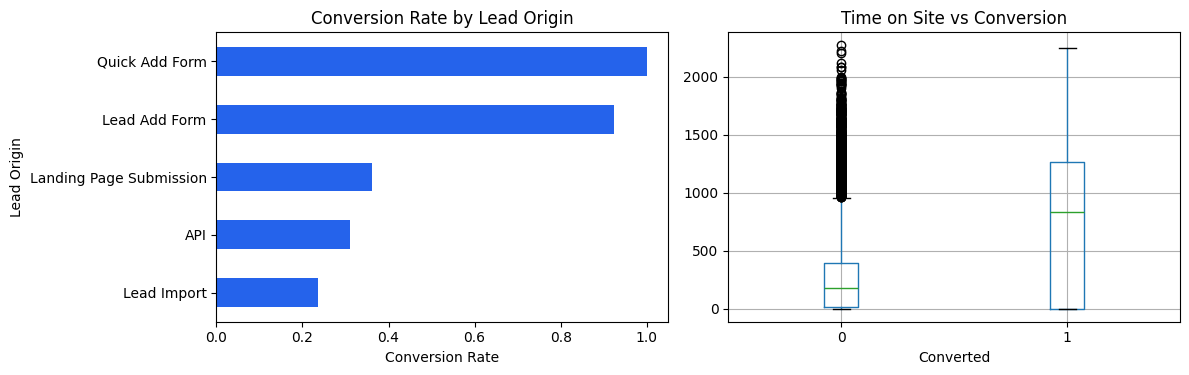

In [7]:
print("Numeric correlation with Converted:")
print(df[['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit', 'Converted']].corr()['Converted'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df.groupby('Lead Origin')['Converted'].mean().sort_values().plot(kind='barh', ax=axes[0], color='#2563eb')
axes[0].set_title('Conversion Rate by Lead Origin')
axes[0].set_xlabel('Conversion Rate')

df.boxplot(column='Total Time Spent on Website', by='Converted', ax=axes[1])
axes[1].set_title('Time on Site vs Conversion')
plt.suptitle('')
plt.tight_layout()
plt.show()

#### NOTE: 1)We exclude Tags because it contains information added after sales contact.
#### 2)Using it could give the model information that would not be available for a new lead.

In [8]:
if 'Tags' in df.columns:
    df = df.drop(columns=['Tags'])
    print("Dropped 'Tags' to avoid leakage.")

Dropped 'Tags' to avoid leakage.


# Step 3: Feature Engineering
Here we prepare the data before giving it to the machine learning model.

In [9]:
y = df['Converted']
X = df.drop(columns=['Converted'])

cat_cols = X.select_dtypes(include='object').columns.tolist()
for c in cat_cols:
    top = X[c].value_counts().nlargest(6).index
    X[c] = X[c].where(X[c].isin(top), other='Other')

X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print("Feature matrix shape:", X_encoded.shape)

Feature matrix shape: (9240, 50)


## Step 4 — Train/Test Split & Scaling
70/30 stratified split to preserve the conversion ratio in both sets.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, train_size=0.7, test_size=0.3, random_state=42, stratify=y
)

num_cols = ['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit']
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (6468, 50)  Test: (2772, 50)


## Step 5 - Building the Model
**Logistic Regression** - selected since there is a requirement for a *probability*
prediction rather than a binary response for lead scoring, in addition to its interpretable
coefficients.

**RFE (Recursive Feature Elimination)** selects the top 15 features.

In [11]:
base_lr = LogisticRegression(max_iter=2000, solver='liblinear')
rfe = RFE(base_lr, n_features_to_select=15)
rfe.fit(X_train, y_train)
selected_features = X_train.columns[rfe.support_].tolist()
print("Selected features:")
for f in selected_features:
    print(" -", f)

X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

model = LogisticRegression(max_iter=2000, solver='liblinear')
model.fit(X_train_sel, y_train)

coef_df = pd.DataFrame({'feature': selected_features, 'coefficient': model.coef_[0]}) \
            .sort_values('coefficient', ascending=False)
print("\nCoefficients (higher = raises lead score):")
coef_df

Selected features:
 - Total Time Spent on Website
 - Lead Origin_Landing Page Submission
 - Lead Origin_Lead Add Form
 - Lead Origin_Lead Import
 - Lead Source_Welingak Website
 - Do Not Email_Yes
 - Last Activity_Email Opened
 - Last Activity_Other
 - Last Activity_SMS Sent
 - Country_Not Provided
 - Specialization_Not Provided
 - What is your current occupation_Not Provided
 - What is your current occupation_Working Professional
 - Last Notable Activity_Other
 - Last Notable Activity_SMS Sent

Coefficients (higher = raises lead score):


,feature,coefficient
12,What is your current occupation_Working Profes...,2.334108
2,Lead Origin_Lead Add Form,1.898361
4,Lead Source_Welingak Website,1.765742
13,Last Notable Activity_Other,1.484664
8,Last Activity_SMS Sent,1.326494
14,Last Notable Activity_SMS Sent,1.156550
0,Total Time Spent on Website,1.097304
9,Country_Not Provided,1.056911
6,Last Activity_Email Opened,1.050599
7,Last Activity_Other,0.584382


## Step 6 — Model Evaluation

In [12]:
y_train_prob = model.predict_proba(X_train_sel)[:, 1]
y_test_prob = model.predict_proba(X_test_sel)[:, 1]

y_pred = (y_test_prob >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix @ 0.5 cutoff:")
print(cm)
print("\nAccuracy:   ", round(accuracy_score(y_test, y_pred), 4))
print("Sensitivity:", round(tp/(tp+fn), 4))
print("Specificity:", round(tn/(tn+fp), 4))
print("Precision:  ", round(tp/(tp+fp), 4))
print("\nTrain AUC:", round(roc_auc_score(y_train, y_train_prob), 4))
print("Test AUC: ", round(roc_auc_score(y_test, y_test_prob), 4))

Confusion Matrix @ 0.5 cutoff:
[[1494  210]
 [ 318  750]]

Accuracy:    0.8095
Sensitivity: 0.7022
Specificity: 0.8768
Precision:   0.7812

Train AUC: 0.9011
Test AUC:  0.8841


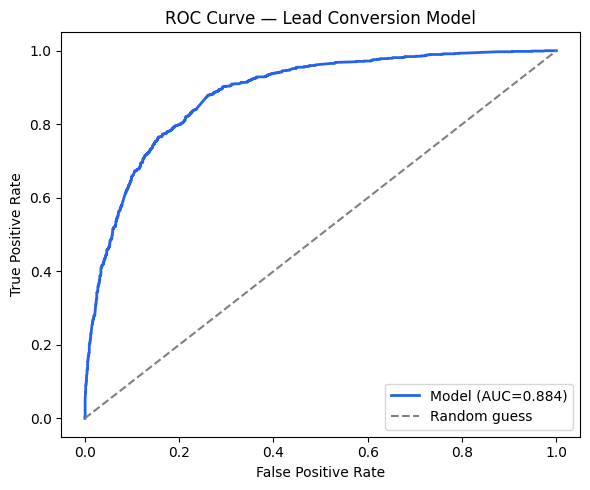

In [13]:
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
auc = roc_auc_score(y_test, y_test_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Model (AUC={auc:.3f})', color='#2563eb', linewidth=2)
plt.plot([0, 1], [0, 1], '--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Lead Conversion Model')
plt.legend()
plt.tight_layout()
plt.show()

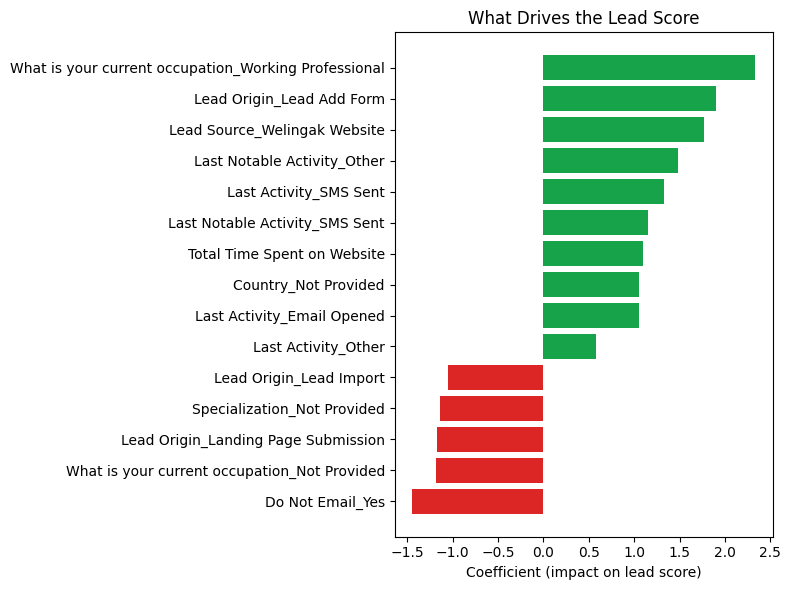

In [14]:
coef_sorted = coef_df.sort_values('coefficient')
colors = ['#dc2626' if v < 0 else '#16a34a' for v in coef_sorted['coefficient']]
plt.figure(figsize=(8, 6))
plt.barh(coef_sorted['feature'], coef_sorted['coefficient'], color=colors)
plt.xlabel('Coefficient (impact on lead score)')
plt.title('What Drives the Lead Score')
plt.tight_layout()
plt.show()

#### Step 7: Generate Lead Scores for All Leads
#### 1)We use the model's predicted probability to give each lead a score from 0 to 100.
#### 2)Then we group the leads into Hot, Warm, and Cold categories.
#### 3)This helps the sales team focus on the most promising leads first.

In [15]:
# Score every lead in the (cleaned, encoded) dataset
X_all = X_encoded.copy()
X_all[num_cols] = scaler.transform(X_all[num_cols])
X_all_sel = X_all[selected_features]

all_probs = model.predict_proba(X_all_sel)[:, 1]
lead_score = (all_probs * 100).round(1)

scored = pd.DataFrame({
    'Actual_Converted': y.values,
    'Conversion_Probability': all_probs.round(4),
    'Lead_Score': lead_score
})

def tier(s):
    if s >= 70:
        return 'Hot'
    elif s >= 40:
        return 'Warm'
    return 'Cold'

scored['Priority_Tier'] = scored['Lead_Score'].apply(tier)
scored = scored.sort_values('Lead_Score', ascending=False).reset_index(drop=True)

print(scored['Priority_Tier'].value_counts())
print()
print("Actual conversion rate by tier:")
print(scored.groupby('Priority_Tier')['Actual_Converted'].mean().round(3))
scored.head(10)

Priority_Tier
Cold    5499
Hot     2248
Warm    1493
Name: count, dtype: int64

Actual conversion rate by tier:
Priority_Tier
Cold    0.139
Hot     0.861
Warm    0.576
Name: Actual_Converted, dtype: float64


,Actual_Converted,Conversion_Probability,Lead_Score,Priority_Tier
0,1,0.9994,99.9,Hot
1,1,0.9993,99.9,Hot
2,1,0.9988,99.9,Hot
3,1,0.9994,99.9,Hot
4,1,0.9990,99.9,Hot
5,1,0.9988,99.9,Hot
6,1,0.9986,99.9,Hot
7,1,0.9992,99.9,Hot
8,1,0.9987,99.9,Hot
9,1,0.9985,99.9,Hot


In [16]:
# Save & download the scored leads
scored.to_csv('final_lead_scores.csv', index=False)
try:
    from google.colab import files
    files.download('final_lead_scores.csv')
except ImportError:
    print("Saved final_lead_scores.csv in the working directory.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Results & Business Recommendations

---

Tier

Score range

Typical % of leads

Actual conversion rate

---

**Hot**

70–100

~24%

**~86%**

---

**Warm**

40–69

~16%

~58%

---

**Cold**

0–39

~60%

~14%

---

**Takeaway:** Conversion rates of Hot-tier leads already exceed 80% target level. The
most effective single move possible is to move sales effort away from Cold-tier leads
(getting equal focus now) towards Hot/Warm-tier leads.

**Recommendations:**

1\. Make sure Hot-tier leads get routed directly to reps without any queue waiting.

2\. Shift Cold-tier leads to automated nurture email sequences rather than live calls.

3\. Improve data gathering process. Fields with blanks for Occupation/Country/Spec
reduce the score; encouraging leads to fill these will improve accuracy.

4\. Focus more on the best performing channels: Reference leads, Welingak Website and
the Lead Add Form sources perform significantly better than other sources.

5\. Re-train the model every 6–12 months.